In [1]:
import numpy as np

# ---------------------------------------------------------------------------
# K+ pass-2 chi2pid parameters (pid_cuts.java lines 438–439)
# ---------------------------------------------------------------------------
MU_KPLUS = 0.082
SIGMA_KPLUS = 0.985

# Lower-bound exponential parameters for p > 2 GeV/c (pid_cuts.java line 443)
LOWER_C = 1.2        # plateau value the exponential decays away from
LOWER_P0 = 2.0       # momentum at which the exponential kicks in
LOWER_TAU = 0.6      # decay constant in GeV/c

# Upper-bound exponential parameters for p > 2.5 GeV/c (pid_cuts.java line 445)
UPPER_C = 2.6        # plateau value the exponential decays away from
UPPER_P0 = 2.5       # momentum at which the upper bound starts contracting
UPPER_TAU = 0.3      # decay constant in GeV/c

# ---------------------------------------------------------------------------
# π+ pass-2 chi2pid parameters (pid_cuts.java lines 428–429)
# ---------------------------------------------------------------------------
MU_PIPLUS = -0.067
SIGMA_PIPLUS = 0.956

# Upper-bound exponential parameters for π+ at p > 3.5 GeV (pid_cuts.java line 433)
# Lower bound stays flat at μ−3σ for all p (no lower-bound exponential for π+)
PIPLUS_UPPER_C = -0.55
PIPLUS_UPPER_P0 = 3.5
PIPLUS_UPPER_TAU = 0.55


# ---------------------------------------------------------------------------
# Private helper
# ---------------------------------------------------------------------------

def _const_plus_exponential(c: float, a: float, tau: float,
                             p0: float, p: np.ndarray) -> np.ndarray:
    """
    Evaluate the helper function used by pid_cuts.java (line 263–264).

        f(p) = c + a * exp( -(p - p0) / tau )

    Parameters
    ----------
    c   : asymptotic plateau (value as p → ∞)
    a   : amplitude of the exponential term at p = p0
    tau : decay constant (GeV/c); controls how quickly the exponential falls
    p0  : reference momentum (GeV/c) at which the exponential term equals *a*
    p   : track momentum array (GeV/c)

    Returns
    -------
    np.ndarray, same shape as *p*
    """
    return c + a * np.exp(-(p - p0) / tau)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()
baseline = matched[((matched["theta"]>5)&(matched["theta"]<35))]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/Baselines/"  #path directory for saving pngs :)
matched=baseline

colors =["green", "blue"]
labels=["K+", "Pi+"]

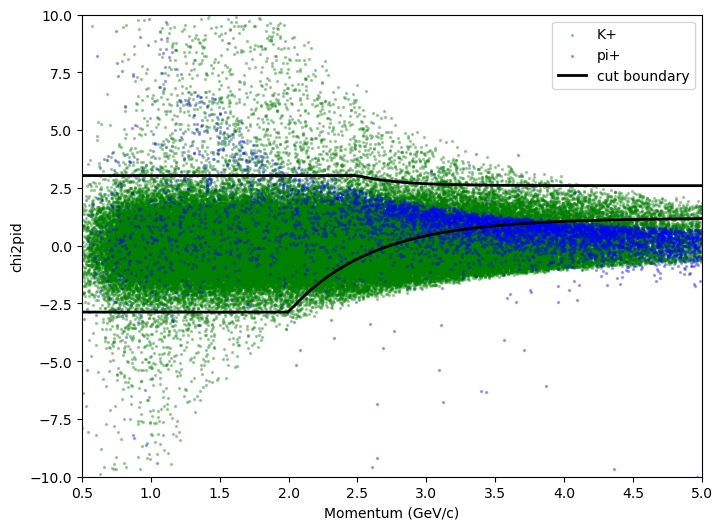

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
matched=matched[matched["mc_matching_pid"]==321]
for pid_val, color, label in [
    (321, "green", "K+"),
    (211, "blue", "pi+")
]:
    subset = matched[matched["pid"] == pid_val]

    ax.scatter(
        subset["p"],
        subset["chi2pid"],
        s=2,
        color=color,
        label=label,
        alpha=0.3
    )

p_vals = np.linspace(matched["p"].min(), matched["p"].max(), 500)

lo_flat = MU_KPLUS - 3.0 * SIGMA_KPLUS
hi_flat = MU_KPLUS + 3.0 * SIGMA_KPLUS

lo_exp = _const_plus_exponential(
    LOWER_C,
    lo_flat - LOWER_C,
    LOWER_TAU,
    LOWER_P0,
    p_vals
)

hi_exp = _const_plus_exponential(
    UPPER_C,
    hi_flat - UPPER_C,
    UPPER_TAU,
    UPPER_P0,
    p_vals
)

lower = np.where(p_vals < 2.0, lo_flat, lo_exp)
upper = np.where(p_vals < 2.5, hi_flat, hi_exp)

# --- plot boundaries ---
ax.plot(p_vals, lower, color="black", linewidth=2, label="cut boundary")
ax.plot(p_vals, upper, color="black", linewidth=2)




ax.set_ylim(-10, 10)
ax.set_xlim(0.5, 5)
ax.set_ylabel("chi2pid")
ax.set_xlabel("Momentum (GeV/c)")
ax.legend()
fig.savefig("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/Baselines/" + "pCutTest.png", dpi=150)
plt.show()

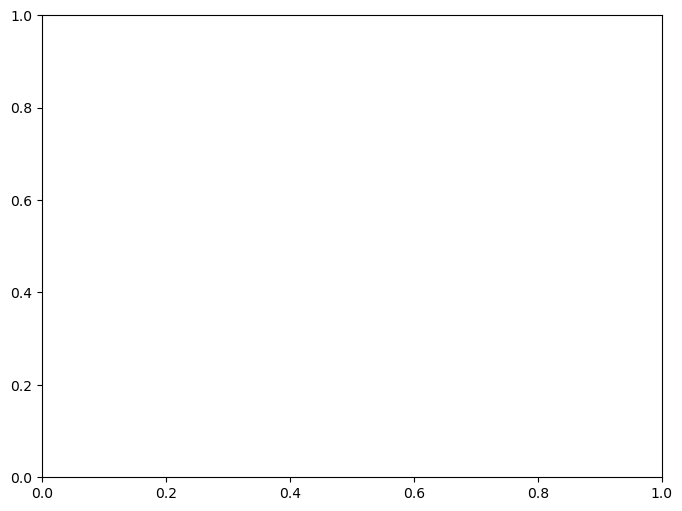

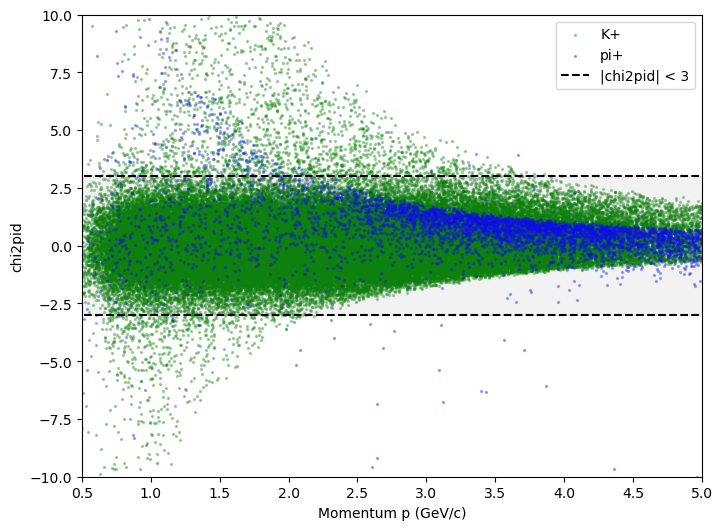

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

ebk = matched[matched["pid"] == 321]

# --- scatter colored by MC truth ---
fig, ax = plt.subplots(figsize=(8, 6))
matched=matched[matched["mc_matching_pid"]==321]
for pid_val, color, label in [
    (321, "green", "K+"),
    (211, "blue", "pi+")
]:
    subset = matched[matched["pid"] == pid_val]

    ax.scatter(
        subset["p"],
        subset["chi2pid"],
        s=2,
        color=color,
        label=label,
        alpha=0.3
    )

# --- SIMPLE CUT BOUNDARIES: |chi2pid| < 3 ---
p_vals = np.linspace(ebk["p"].min(), ebk["p"].max(), 500)

ax.plot(p_vals, 3 * np.ones_like(p_vals), "k--", label="|chi2pid| < 3")
ax.plot(p_vals, -3 * np.ones_like(p_vals), "k--")

# optional shading of accepted region
ax.fill_between(p_vals, -3, 3, color="gray", alpha=0.1)

# --- styling ---
ax.set_ylim(-10, 10)
ax.set_xlim(0.5, 5)

ax.set_xlabel("Momentum p (GeV/c)")
ax.set_ylabel("chi2pid")


ax.legend()
fig.savefig("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/Baselines/" + "CutTest.png", dpi=150)
plt.show()

In [ ]:
print()